In [2]:
df = spark.read.csv(
    "hdfs://namenode:9000/user/sanjay/dataset/US_Accidents_March23.csv",
    header=True,
    inferSchema=False
)
print(f"✅ Loaded! Columns: {len(df.columns)}")
df.printSchema()

✅ Loaded! Columns: 46
root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: string (nullable = true)
 |-- Start_Time: string (nullable = true)
 |-- End_Time: string (nullable = true)
 |-- Start_Lat: string (nullable = true)
 |-- Start_Lng: string (nullable = true)
 |-- End_Lat: string (nullable = true)
 |-- End_Lng: string (nullable = true)
 |-- Distance(mi): string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: string (nullable = true)
 |-- Temperature(F): string (nullable = true)
 |-- Wind_Chill(F): string (nullable = true)
 |-- Humidity(%): string (nullable = true)
 |-- Pressure(in): string (nullable = 

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("US_Accidents_Preprocessing") \
    .master("local[*]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("✅ Spark Session Started!")
print("Spark Version:", spark.version)

✅ Spark Session Started!
Spark Version: 3.5.0


In [3]:
from pyspark.sql.functions import col, hour, dayofweek, month, year, when, to_timestamp

# ── DROP IRRELEVANT COLUMNS ──────────────────────────────
drop_cols = ['ID', 'Description', 'Number', 'Street', 'Zipcode',
             'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp',
             'Wind_Direction', 'Turning_Loop']
df = df.drop(*drop_cols)
print(f"✅ Dropped columns. Remaining: {len(df.columns)} columns")

# ── DROP ROWS WITH NULL KEY COLUMNS ─────────────────────
df = df.dropna(subset=['Severity', 'Start_Lat', 'Start_Lng', 'City', 'State'])
print(f"✅ Dropped null rows!")

# ── FILL MISSING NUMERICAL VALUES ───────────────────────
num_fill = {
    'Temperature(F)': '60.0',
    'Humidity(%)': '65.0',
    'Pressure(in)': '29.9',
    'Visibility(mi)': '10.0',
    'Wind_Speed(mph)': '8.0',
    'Precipitation(in)': '0.0',
    'Wind_Chill(F)': '55.0'
}
df = df.fillna(num_fill)

# ── FILL MISSING CATEGORICAL VALUES ─────────────────────
cat_fill = {
    'Weather_Condition': 'Clear',
    'Sunrise_Sunset': 'Day',
    'Civil_Twilight': 'Day',
    'Nautical_Twilight': 'Day',
    'Astronomical_Twilight': 'Day'
}
df = df.fillna(cat_fill)
print("✅ Missing values handled!")
print(f"Remaining columns: {df.columns}")

✅ Dropped columns. Remaining: 36 columns
✅ Dropped null rows!
✅ Missing values handled!
Remaining columns: ['Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'City', 'County', 'State', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [4]:
# ── FEATURE ENGINEERING ──────────────────────────────────

# Convert Start_Time to timestamp
df = df.withColumn("Start_Time", to_timestamp(col("Start_Time")))

# Extract time features
df = df.withColumn("Hour", hour(col("Start_Time")))
df = df.withColumn("DayOfWeek", dayofweek(col("Start_Time")))
df = df.withColumn("Month", month(col("Start_Time")))
df = df.withColumn("Year", year(col("Start_Time")))

# Rush hour flag
df = df.withColumn("Is_RushHour",
    when((col("Hour") >= 7) & (col("Hour") <= 9), 1)
    .when((col("Hour") >= 16) & (col("Hour") <= 18), 1)
    .otherwise(0))

# Weekend flag
df = df.withColumn("Is_Weekend",
    when(col("DayOfWeek").isin([1, 7]), 1).otherwise(0))

# Cast Severity to integer
df = df.withColumn("Severity", col("Severity").cast("integer"))

print("✅ Feature Engineering Done!")
print(f"Total columns now: {len(df.columns)}")
df.select("Severity", "Hour", "DayOfWeek", "Month", "Year", "Is_RushHour", "Is_Weekend").show(5)

✅ Feature Engineering Done!
Total columns now: 42
+--------+----+---------+-----+----+-----------+----------+
|Severity|Hour|DayOfWeek|Month|Year|Is_RushHour|Is_Weekend|
+--------+----+---------+-----+----+-----------+----------+
|       3|   5|        2|    2|2016|          0|         0|
|       2|   6|        2|    2|2016|          0|         0|
|       2|   6|        2|    2|2016|          0|         0|
|       3|   7|        2|    2|2016|          1|         0|
|       2|   7|        2|    2|2016|          1|         0|
+--------+----+---------+-----+----+-----------+----------+
only showing top 5 rows



In [5]:
# ── SEVERITY DISTRIBUTION ────────────────────────────────
print("📊 Severity Distribution:")
df.groupBy("Severity").count().orderBy("Severity").show()

# ── TOP 10 STATES ────────────────────────────────────────
print("📊 Top 10 States by Accident Count:")
df.groupBy("State").count().orderBy("count", ascending=False).show(10)

# ── RUSH HOUR ANALYSIS ───────────────────────────────────
print("📊 Rush Hour vs Non-Rush Hour:")
df.groupBy("Is_RushHour").count().orderBy("Is_RushHour").show()

print(f"\n✅ Total Records after preprocessing: {df.count()}")

📊 Severity Distribution:
+--------+-------+
|Severity|  count|
+--------+-------+
|       1|  67363|
|       2|6156764|
|       3|1299324|
|       4| 204690|
+--------+-------+

📊 Top 10 States by Accident Count:
+-----+-------+
|State|  count|
+-----+-------+
|   CA|1741422|
|   FL| 880159|
|   TX| 582837|
|   SC| 382557|
|   NY| 347932|
|   NC| 338199|
|   VA| 303301|
|   PA| 296620|
|   MN| 192079|
|   OR| 179655|
+-----+-------+
only showing top 10 rows

📊 Rush Hour vs Non-Rush Hour:
+-----------+-------+
|Is_RushHour|  count|
+-----------+-------+
|          0|4610134|
|          1|3118007|
+-----------+-------+


✅ Total Records after preprocessing: 7728141


In [7]:
print("Saving preprocessed data to HDFS...")

df.write.mode("overwrite").parquet(
    "hdfs://namenode:9000/user/sanjay/preprocessed/"
)

print("✅ Saved to HDFS at /user/sanjay/preprocessed/")
print("🎉 Preprocessing Complete!")

Saving preprocessed data to HDFS...
✅ Saved to HDFS at /user/sanjay/preprocessed/
🎉 Preprocessing Complete!


In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

# ── 1. SEVERITY DISTRIBUTION ─────────────────────────────
severity_df = df.groupBy("Severity").count().orderBy("Severity").toPandas()

plt.figure(figsize=(8, 5))
plt.bar(severity_df['Severity'], severity_df['count'], 
        color=['green', 'yellow', 'orange', 'red'])
plt.title('Accidents by Severity Level', fontsize=14)
plt.xlabel('Severity')
plt.ylabel('Count')
plt.xticks([1, 2, 3, 4])
plt.tight_layout()
plt.savefig('/home/jovyan/work/severity.png')
plt.show()
print("✅ Severity chart saved!")

# ── 2. TOP 10 STATES ─────────────────────────────────────
states_df = df.groupBy("State").count().orderBy("count", ascending=False).limit(10).toPandas()

plt.figure(figsize=(10, 5))
plt.bar(states_df['State'], states_df['count'], color='steelblue')
plt.title('Top 10 States by Accident Count', fontsize=14)
plt.xlabel('State')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('/home/jovyan/work/states.png')
plt.show()
print("✅ States chart saved!")

# ── 3. ACCIDENTS BY HOUR ─────────────────────────────────
hour_df = df.groupBy("Hour").count().orderBy("Hour").toPandas()

plt.figure(figsize=(12, 5))
plt.plot(hour_df['Hour'], hour_df['count'], marker='o', color='tomato')
plt.title('Accidents by Hour of Day', fontsize=14)
plt.xlabel('Hour')
plt.ylabel('Count')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.savefig('/home/jovyan/work/hourly.png')
plt.show()
print("✅ Hourly chart saved!")

✅ Severity chart saved!
✅ States chart saved!
✅ Hourly chart saved!


📊 Severity Distribution:


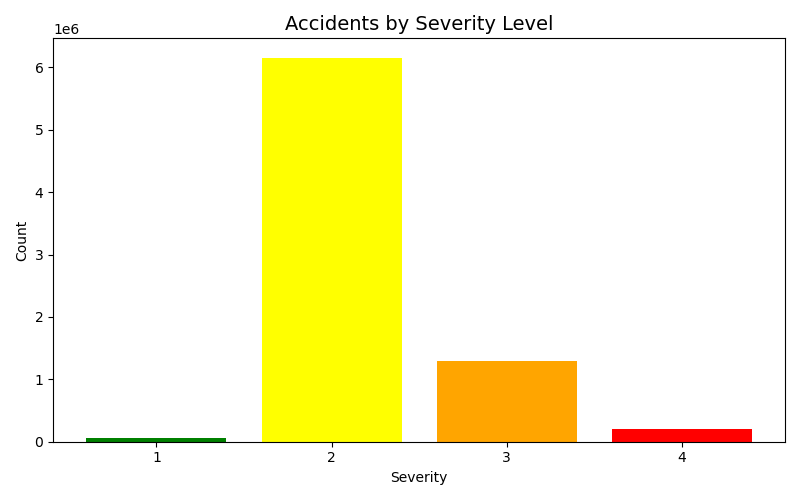

📊 Top 10 States:


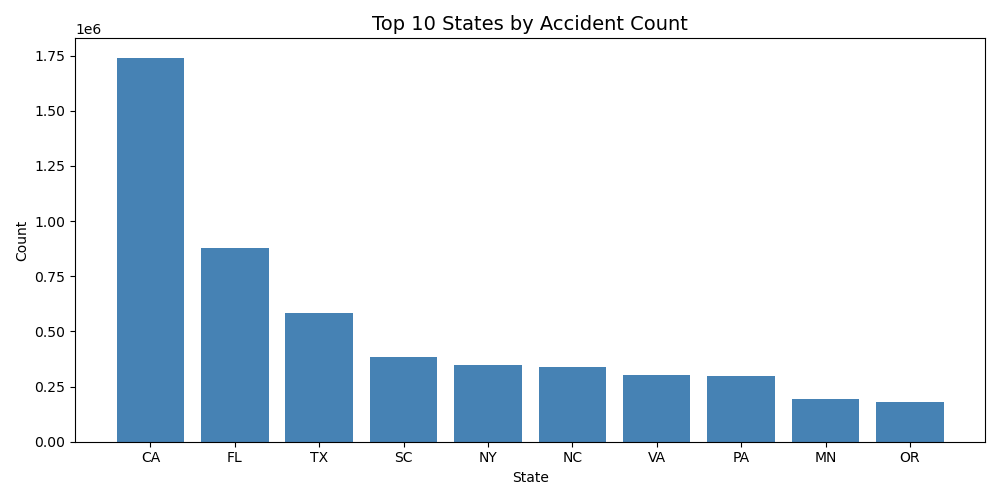

📊 Accidents by Hour:


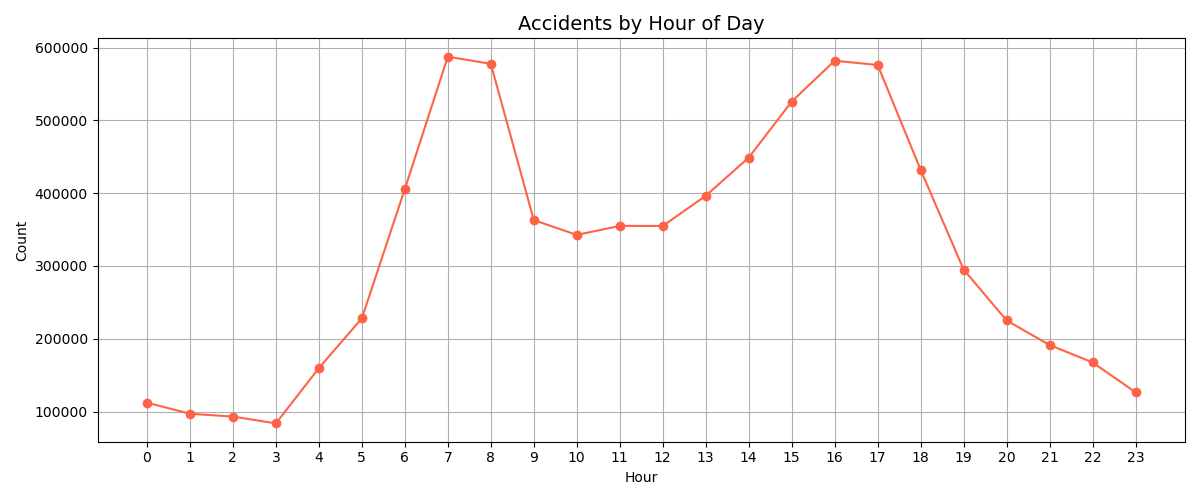

In [9]:
from IPython.display import Image, display

print("📊 Severity Distribution:")
display(Image('/home/jovyan/work/severity.png'))

print("📊 Top 10 States:")
display(Image('/home/jovyan/work/states.png'))

print("📊 Accidents by Hour:")
display(Image('/home/jovyan/work/hourly.png'))